In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
# --- Git Clone & Setup ---
REPO_URL = "https://github.com/DanielQH07/tranSTR_Casual.git" 
REPO_NAME = "tranSTR_Casual"
BRANCH = "origin" 

if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_URL}...")
    !git clone {REPO_URL} -b {BRANCH}
else:
    print("Repo already exists.")

# Change Directory to the repo root 
if os.path.basename(os.getcwd()) != REPO_NAME:
    try:
        target_dir = os.path.join(os.getcwd(), REPO_NAME, "causalvid")
        if os.path.exists(target_dir):
             os.chdir(target_dir)
        elif os.path.exists(REPO_NAME):
             os.chdir(REPO_NAME)
        
        print(f"Changed directory to: {os.getcwd()}")
    except Exception as e:
             print(f"Could not set working directory: {e}")

Cloning https://github.com/DanielQH07/tranSTR_Casual.git...
Cloning into 'tranSTR_Casual'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 128 (delta 64), reused 101 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 365.23 KiB | 11.07 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Changed directory to: /kaggle/working/tranSTR_Casual


In [ ]:
# CELL 2: Auth + Dependencies (Colab/Kaggle)
print('=== CELL 2: Auth + Dependencies ===')
%pip install -q -U huggingface_hub wandb kaggle kagglehub

import os
import wandb
from huggingface_hub import login, HfApi, hf_hub_download, list_repo_tree

# Optional: load secrets from Colab
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    wandb_key = userdata.get('WANDB_API_KEY')
    kaggle_user = userdata.get('KAGGLE_USERNAME')
    kaggle_key = userdata.get('KAGGLE_KEY')

    if kaggle_user and kaggle_key:
        os.environ['KAGGLE_USERNAME'] = kaggle_user
        os.environ['KAGGLE_KEY'] = kaggle_key
        print('✅ Kaggle credentials loaded from Colab Secrets')

    if hf_token:
        login(token=hf_token)
        print('✅ HuggingFace login OK')
    else:
        print('⚠️ HF_TOKEN not found in Colab Secrets')

    if wandb_key:
        wandb.login(key=wandb_key)
        print('✅ W&B login OK')
    else:
        print('⚠️ WANDB_API_KEY not found in Colab Secrets')
except Exception as e:
    print(f'ℹ️ Colab secrets not available: {e}')
    print('You can still login manually if needed.')

=== CELL 2 ===


In [ ]:
# CELL 2.5: Runtime hotfix for transformers tokenizer API
print('=== CELL 2.5: Patch networks/model.py for tokenizer compatibility ===')

from pathlib import Path

model_py = Path('networks/model.py')
if not model_py.exists():
    raise FileNotFoundError(f'Not found: {model_py}. Please run clone/setup cell first.')

src = model_py.read_text(encoding='utf-8')
old = "tokenized_queries = self.tokenizer.batch_encode_plus(text_queries, padding='longest', return_tensors='pt')"
new = "tokenized_queries = self.tokenizer(text_queries, padding='longest', truncation=True, return_tensors='pt')"

if old in src:
    src = src.replace(old, new)
    model_py.write_text(src, encoding='utf-8')
    print('✅ Patched batch_encode_plus -> tokenizer(...)')
else:
    print('ℹ️ Patch not needed (already compatible).')

In [4]:
# CELL 3: Imports
print('=== CELL 3: Imports ===')
import os, torch, numpy as np, pandas as pd, tarfile, shutil, json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from utils.util import set_seed, set_gpu_devices
from DataLoader import VideoQADataset
from networks.model import VideoQAmodel
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
print('Imports OK')

=== CELL 3: Imports ===
Imports OK


In [5]:
# CELL 4: Train/Eval functions (No AMP - Safe for DeBERTa)
print('=== CELL 4 ===')

def train_epoch(model, optimizer, loader, xe, device, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ff, of, q, a, ans_id, _ = batch
        ff, of, tgt = ff.to(device), of.to(device), ans_id.to(device)
        
        # No autocast - DeBERTa has issues with fp16
        out = model(ff, of, q, a)
        loss = xe(out, tgt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (out.argmax(-1) == tgt).sum().item()
        total += tgt.size(0)
    return total_loss / len(loader), correct / total * 100

def eval_epoch(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            ff, of, q, a, ans_id, _ = batch
            out = model(ff.to(device), of.to(device), q, a)
            correct += (out.argmax(-1) == ans_id.to(device)).sum().item()
            total += ans_id.size(0)
    return correct / total * 100

print('Functions defined (No AMP - DeBERTa safe)')


=== CELL 4 ===
Functions defined (No AMP - DeBERTa safe)


In [ ]:
# CELL 5 + 6: Setup Paths & Config (Colab + KaggleHub)
print('=== CELL 5+6: Paths & Config ===')

import kagglehub
from pathlib import Path

# ============================================
# DATASET SOURCES (KaggleHub)
# ============================================
KAGGLE_VIT_DATASET = 'danielq07/vit-features-full-merged'
KAGGLE_OBJ_DATASET = 'danielq07/object-detection-causal-full'
KAGGLE_ANNO_DATASET = 'lusnaw/text-annotation'
KAGGLE_SPLIT_DATASET = 'danielq07/casual-vid-data-split'

# ============================================
# HELPERS
# ============================================
def _find_dir_containing(root, target_name):
    root = Path(root)
    if not root.exists():
        return None
    for p in root.rglob('*'):
        if p.is_dir() and p.name.lower() == target_name.lower():
            return str(p)
    return None

def _find_dir_with_ext(root, ext):
    root = Path(root)
    if not root.exists():
        return None
    counts = {}
    for p in root.rglob(f'*{ext}'):
        parent = str(p.parent)
        counts[parent] = counts.get(parent, 0) + 1
    if not counts:
        return None
    return max(counts.items(), key=lambda x: x[1])[0]

# ============================================
# DOWNLOAD / RESOLVE PATHS
# ============================================
print('\nDownloading datasets from KaggleHub (cached if already downloaded)...')
vit_root = kagglehub.dataset_download(KAGGLE_VIT_DATASET)
obj_root = kagglehub.dataset_download(KAGGLE_OBJ_DATASET)
anno_root = kagglehub.dataset_download(KAGGLE_ANNO_DATASET)
split_root = kagglehub.dataset_download(KAGGLE_SPLIT_DATASET)

VIT_FEATURE_PATH = _find_dir_with_ext(vit_root, '.pt') or vit_root
OBJ_FEATURE_PATH = _find_dir_with_ext(obj_root, '.pkl') or obj_root
ANNOTATION_PATH = _find_dir_containing(anno_root, 'QA') or anno_root
SPLIT_DIR = _find_dir_containing(split_root, 'split') or split_root

# ============================================
# WORKING DIRECTORIES
# ============================================
BASE = '/content/working' if os.path.exists('/content') else ('/kaggle/working' if os.path.exists('/kaggle/working') else os.getcwd())
MODEL_DIR = os.path.join(BASE, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================
# VERIFY PATHS
# ============================================
print('\n--- Path Verification ---')

def verify_path(name, path):
    if os.path.exists(path):
        items = os.listdir(path)[:5]
        print(f'✅ {name}')
        print(f'   Path: {path}')
        print(f'   Sample: {items}')
        return True
    print(f'❌ {name}: NOT FOUND')
    print(f'   Path: {path}')
    return False

all_ok = True
all_ok &= verify_path('ViT Features', VIT_FEATURE_PATH)
all_ok &= verify_path('Object Features', OBJ_FEATURE_PATH)
all_ok &= verify_path('Annotations', ANNOTATION_PATH)
all_ok &= verify_path('Splits', SPLIT_DIR)
if not all_ok:
    print('\n⚠️ Please check dataset slugs / permissions.')

# ============================================
# CONFIG
# ============================================
RUN_TRAINING = True
HF_REPO_ID = 'DanielQ07/transtr-causalvid-weights'
HF_MODEL_FILENAME = 'best_model.ckpt'
LAST_CKPT_FILENAME = 'last_checkpoint.ckpt'
WANDB_PROJECT = 'transtr-causalvid'

class Config:
    video_feature_root = VIT_FEATURE_PATH
    object_feature_path = OBJ_FEATURE_PATH
    sample_list_path = ANNOTATION_PATH
    split_dir_txt = SPLIT_DIR

    # Paper-aligned video/object setup
    topK_frame = 16   # T=16 sampled frames per video
    frames = 16
    objs = 20         # S=20 objects per frame

    # Paper hyper-parameters
    Kf = 5            # selected frame tokens for hierarchy
    Ko = 12           # selected object tokens for hierarchy
    topK_obj = 12     # keep for compatibility with existing code paths

    frame_feat_dim = 1024
    obj_feat_dim = 2053
    d_model = 768
    word_dim = 768
    nheads = 8
    num_encoder_layers = 2
    num_decoder_layers = 2
    normalize_before = True
    activation = 'gelu'
    dropout = 0.3
    encoder_dropout = 0.3

    text_encoder_type = 'microsoft/deberta-base'
    freeze_text_encoder = False
    text_encoder_lr = 1e-5
    text_pool_mode = 1

    bs = 32
    lr = 1e-5
    epoch = 15
    gpu = 0
    patience = 5
    gamma = 0.1
    decay = 1e-4
    n_query = 5

    hard_eval = False
    pos_ratio = 1.0
    neg_ratio = 1.0
    a = 1.0
    use_amp = False
    num_workers = 4

args = Config()
set_gpu_devices(args.gpu)
set_seed(999)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'\nDevice: {device}')
print(f'Config loaded | bs={args.bs}, epoch={args.epoch}')
print('\nPaper-Detail Check:')
print(f'  T (frames)            = {args.topK_frame}')
print(f'  S (objects/frame)     = {args.objs}')
print(f'  Text encoder          = {args.text_encoder_type}')
print(f'  Optimizer LR          = {args.lr}')
print(f'  Hidden dim d          = {args.d_model}')
print(f'  Kf (frame top-k)      = {args.Kf}')
print(f'  Ko (object top-k)     = {args.Ko}')

=== CELL 5+6: Paths & Config ===

--- Path Verification ---
✅ ViT Features
   Path: /kaggle/input/vit-features-full-merged
   Sample: ['tpWnc0aKcE4_000037_000047.pt', 'j1pFhyRWxes_000099_000109.pt', 'bQ1hlf8GDbU_000685_000695.pt', 'xeOVJxXfMqA_000067_000077.pt', 'SsYyb8Vmuxk_000020_000030.pt']
✅ Object Features
   Path: /kaggle/input/object-detection-causal-full
   Sample: ['features_node_4_FULL', 'features_node_5_FULL', 'features_node_2_FULL', 'features_node_3_FULL', 'features_node_0_FULL']
✅ Annotations
   Path: /kaggle/input/qa-casualvqa/QA
   Sample: ['P-JmNb-FcLk_000041_000051', '2VBmRPrfNZY_000000_000010', '_muKn2ZeLK0_000018_000028', 'PKmebfLRHDI_000393_000403', 'qCpr1QMNpiI_000602_000612']
✅ Splits
   Path: /kaggle/input/casual-vid-data-split/split
   Sample: ['valid.pkl', 'train.pkl', 'test.pkl']

Device: cuda
Config loaded!


In [ ]:
# CELL 7: Create Datasets with Verification
print('=== CELL 7: Datasets ===')

# Set to None for full training set
MAX_TRAIN_SAMPLES = None
PIN_MEMORY = torch.cuda.is_available()

print('\n--- Creating TRAIN dataset ---')
train_ds = VideoQADataset(
    split='train',
    n_query=args.n_query,
    obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    object_feature_path=args.object_feature_path,
    split_dir=args.split_dir_txt,
    topK_frame=args.topK_frame,
    max_samples=MAX_TRAIN_SAMPLES,
    verbose=True
)

print('\n--- Creating VAL dataset ---')
val_ds = VideoQADataset(
    split='val',
    n_query=args.n_query,
    obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    object_feature_path=args.object_feature_path,
    split_dir=args.split_dir_txt,
    topK_frame=args.topK_frame,
    max_samples=None,
    verbose=True
)

print('\n--- Creating TEST dataset ---')
test_ds = VideoQADataset(
    split='test',
    n_query=args.n_query,
    obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    object_feature_path=args.object_feature_path,
    split_dir=args.split_dir_txt,
    topK_frame=args.topK_frame,
    max_samples=None,
    verbose=True
)

train_loader = DataLoader(train_ds, args.bs, shuffle=True, num_workers=args.num_workers, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, args.bs, shuffle=False, num_workers=args.num_workers, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, args.bs, shuffle=False, num_workers=args.num_workers, pin_memory=PIN_MEMORY)

print('\n' + '='*60)
print('DATASET SUMMARY')
print('='*60)
print(f'Train: {len(train_ds)} samples -> {len(train_loader)} batches')
print(f'Val:   {len(val_ds)} samples -> {len(val_loader)} batches')
print(f'Test:  {len(test_ds)} samples -> {len(test_loader)} batches')
print(f'pin_memory={PIN_MEMORY}')
print('='*60)

if len(train_ds) > 0:
    print('\nSanity check: Loading first batch...')
    try:
        ff, of, qns, ans, ans_id, keys = next(iter(train_loader))
        print(f'  ViT features: {ff.shape}')
        print(f'  Object features: {of.shape}')
        print(f'  Answer IDs: {ans_id[:8]}')
        print('Sanity check PASSED!')
    except Exception as e:
        print(f'  ERROR: {e}')
        import traceback
        traceback.print_exc()

=== CELL 7: Datasets ===

--- Creating TRAIN dataset ---
[train] Object feature format: kaggle_subdirs
[train] Loaded 18776 video IDs from /kaggle/input/casual-vid-data-split/split/train.pkl
[train] Limited to 2000 videos
[train] ViT: 2000, Obj: 2000, Both: 2000
[train] Final: 12000 QA pairs

--- Creating VAL dataset ---
[val] Object feature format: kaggle_subdirs
[val] Loaded 2695 video IDs from /kaggle/input/casual-vid-data-split/split/valid.pkl
[val] ViT: 2695, Obj: 2695, Both: 2695
[val] Final: 16170 QA pairs

--- Creating TEST dataset ---
[test] Object feature format: kaggle_subdirs
[test] Loaded 5429 video IDs from /kaggle/input/casual-vid-data-split/split/test.pkl
[test] ViT: 5429, Obj: 5429, Both: 5429
[test] Final: 32574 QA pairs

DATASET SUMMARY
Train: 12000 samples -> 1500 batches
Val:   16170 samples -> 2022 batches
Test:  32574 samples -> 4072 batches

Sanity check: Loading first batch...
  ViT features: torch.Size([8, 16, 1024])
  Object features: torch.Size([8, 16, 20, 2

In [ ]:
# CELL 8: Model + W&B Init
print('=== CELL 8: Model ===')
cfg = {k: v for k, v in Config.__dict__.items() if not k.startswith('_')}
cfg['device'] = device
cfg['topK_frame'] = args.Kf
cfg['topK_obj'] = args.Ko
model = VideoQAmodel(**cfg)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
scheduler = ReduceLROnPlateau(optimizer, 'max', factor=args.gamma, patience=args.patience)
model.to(device)
xe = nn.CrossEntropyLoss()
scaler = None  # keep no-AMP path for stability

save_path = os.path.join(MODEL_DIR, HF_MODEL_FILENAME)
last_ckpt_path = os.path.join(MODEL_DIR, LAST_CKPT_FILENAME)

# W&B
wandb_config = {k: v for k, v in Config.__dict__.items() if not k.startswith('_') and not callable(v)}
wandb_config.update({
    'model_dir': MODEL_DIR,
    'hf_repo_id': HF_REPO_ID,
    'run_training': RUN_TRAINING,
    'max_train_samples': globals().get('MAX_TRAIN_SAMPLES', None)
})
if wandb.run is None:
    wandb.init(
        project=WANDB_PROJECT,
        name=f'transtr-bs{args.bs}-ep{args.epoch}',
        config=wandb_config,
        save_code=True
    )
print(f'Model: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')
print(f'Using Kf={args.Kf}, Ko={args.Ko} in model hierarchy')

=== CELL 8: Model ===


config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

2026-01-14 16:22:02.459683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768407722.670125      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768407722.725029      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768407723.220445      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768407723.220484      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768407723.220486      24 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

Model: 215.6M params


In [ ]:
# CELL 9: Training + W&B + Last Checkpoint Resume
print('=== CELL 9: Training ===')

best_acc = 0.0
best_epoch = 0
start_epoch = 1
RESUME_FROM_WANDB_LAST = True

# Try resume last checkpoint from W&B artifact first
if RESUME_FROM_WANDB_LAST and wandb.run is not None:
    try:
        artifact = wandb.run.use_artifact('last-checkpoint-transtr:latest')
        art_dir = artifact.download()
        art_ckpt = os.path.join(art_dir, LAST_CKPT_FILENAME)
        if os.path.exists(art_ckpt):
            shutil.copy2(art_ckpt, last_ckpt_path)
            print(f'✅ Pulled last checkpoint from W&B: {art_ckpt}')
    except Exception as e:
        print(f'ℹ️ No W&B last checkpoint artifact found: {e}')

# Resume from local last checkpoint if exists
if os.path.exists(last_ckpt_path):
    try:
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'], strict=False)
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        best_acc = float(ckpt.get('best_acc', 0.0))
        best_epoch = int(ckpt.get('best_epoch', 0))
        start_epoch = int(ckpt.get('epoch', 0)) + 1
        print(f'✅ Resumed local last checkpoint: epoch={start_epoch-1}, best={best_acc:.2f}%')
    except Exception as e:
        print(f'⚠️ Resume failed, training from scratch: {e}')

if RUN_TRAINING:
    if start_epoch > args.epoch:
        print(f'Checkpoint already reached target epoch={args.epoch}. Skipping training.')
    else:
        for ep in range(start_epoch, args.epoch + 1):
            loss, acc = train_epoch(model, optimizer, train_loader, xe, device, scaler)
            val_acc = eval_epoch(model, val_loader, device)
            scheduler.step(val_acc)
            print(f'Ep {ep}: Loss={loss:.4f}, Train={acc:.1f}%, Val={val_acc:.1f}%')

            # Save last checkpoint every epoch
            ckpt = {
                'epoch': ep,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_acc': float(max(best_acc, val_acc)),
                'best_epoch': int(best_epoch),
                'config': wandb.config.as_dict() if wandb.run else {}
            }
            torch.save(ckpt, last_ckpt_path)

            # Log metrics
            wandb.log({
                'epoch': ep,
                'train/loss': loss,
                'train/acc': acc,
                'val/acc': val_acc,
                'lr': optimizer.param_groups[0]['lr'],
                'best_acc_so_far': max(best_acc, val_acc)
            })

            # Upload last checkpoint artifact each epoch
            last_art = wandb.Artifact('last-checkpoint-transtr', type='model')
            last_art.add_file(last_ckpt_path, name=LAST_CKPT_FILENAME)
            wandb.log_artifact(last_art, aliases=['latest', f'epoch-{ep}'])

            # Save best checkpoint
            if val_acc > best_acc:
                best_acc = val_acc
                best_epoch = ep
                torch.save(model.state_dict(), save_path)
                print('  ✅ Saved best model')

                best_art = wandb.Artifact('best-model-transtr', type='model', metadata={'best_epoch': ep, 'best_val_acc': float(val_acc)})
                best_art.add_file(save_path, name=HF_MODEL_FILENAME)
                wandb.log_artifact(best_art, aliases=['best', f'epoch-{ep}'])

        print(f'\nBest Val: {best_acc:.2f}% at epoch {best_epoch}')

    wandb.run.summary['best_val_acc'] = float(best_acc)
    wandb.run.summary['best_epoch'] = int(best_epoch)

    if os.path.exists(save_path):
        try:
            api = HfApi()
            api.create_repo(repo_id=HF_REPO_ID, repo_type='model', exist_ok=True)
            api.upload_file(path_or_fileobj=save_path, path_in_repo=HF_MODEL_FILENAME, repo_id=HF_REPO_ID, repo_type='model')
            print('✅ Uploaded best model to HuggingFace')
        except Exception as e:
            print(f'Upload failed: {e}')
else:
    print('Skipping training (RUN_TRAINING=False)')

=== CELL 10: TEST Set Evaluation ===

📥 Downloading best_model.ckpt from HuggingFace (DanielQ07/transtr-causalvid-weights)...


best_model.ckpt:   0%|          | 0.00/863M [00:00<?, ?B/s]

✅ Downloaded to: /kaggle/working/models/best_model.ckpt
🔧 Loading weights...
Load status: <All keys matched successfully>

📊 Running Detailed Evaluation on TEST Set...


  0%|          | 0/4072 [00:00<?, ?it/s]


EVALUATION RESULTS - TEST SET
Description               ==>   0.00%  (0/5429)
Explanation               ==>   0.00%  (0/5429)
Predictive-Answer         ==>   0.00%  (0/5429)
Predictive-Reason         ==>   0.00%  (0/5429)
Counterfactual-Answer     ==>   0.00%  (0/5429)
Counterfactual-Reason     ==>   0.00%  (0/5429)
------------------------------------------------------------
PAR                       ==>   0.00%  (0/5429 paired)
CAR                       ==>   0.00%  (0/5429 paired)
------------------------------------------------------------
Acc (ALL)                 ==>   0.00%  ((D+E+PAR+CAR)/4)


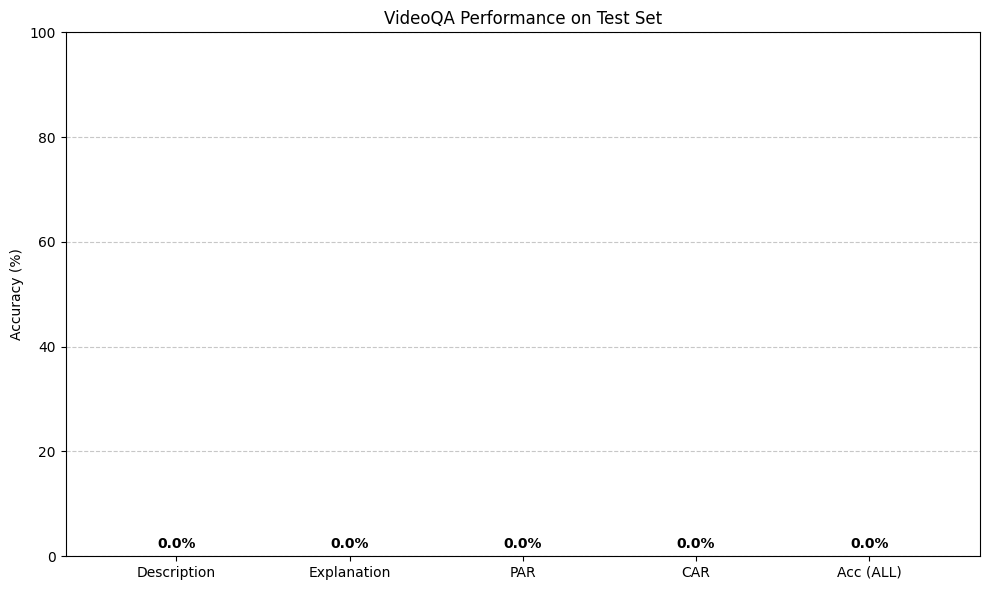

{'Description': np.float64(0.0),
 'Explanation': np.float64(0.0),
 'Predictive-Answer': np.float64(0.0),
 'Predictive-Reason': np.float64(0.0),
 'Counterfactual-Answer': np.float64(0.0),
 'Counterfactual-Reason': np.float64(0.0),
 'PAR': np.float64(0.0),
 'CAR': np.float64(0.0),
 'Acc (ALL)': np.float64(0.0)}

In [ ]:
# CELL 10: Detailed Test Evaluation + W&B logging
print('=== CELL 10: TEST Set Evaluation ===')
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

HF_REPO_ID = 'DanielQ07/transtr-causalvid-weights'
HF_FILENAME = 'best_model.ckpt'
LOCAL_MODEL_PATH = os.path.join(MODEL_DIR, HF_FILENAME)

if not os.path.exists(LOCAL_MODEL_PATH):
    print(f"\n📥 Downloading {HF_FILENAME} from HuggingFace ({HF_REPO_ID})...")
    try:
        model_path = hf_hub_download(repo_id=HF_REPO_ID, filename=HF_FILENAME, local_dir=MODEL_DIR)
        print(f"✅ Downloaded to: {model_path}")
        LOCAL_MODEL_PATH = model_path
    except Exception as e:
        print(f"❌ Failed to download model: {e}")
else:
    print(f"📂 Found local model at: {LOCAL_MODEL_PATH}")

if os.path.exists(LOCAL_MODEL_PATH):
    print('🔧 Loading weights...')
    state = torch.load(LOCAL_MODEL_PATH, map_location=device)
    if isinstance(state, dict) and 'model_state_dict' in state:
        state = state['model_state_dict']
    msg = model.load_state_dict(state, strict=False)
    print(f'Load status: {msg}')
else:
    print('⚠️ No model weights found, evaluating random weights.')


def evaluate_detailed(model, loader, device, dataset_df):
    model.eval()
    results = {}

    print('\n📊 Running Detailed Evaluation on TEST Set...')
    with torch.no_grad():
        for batch in tqdm(loader):
            ff, of, qns, ans_word, ans_id, qns_keys = batch
            ff = ff.to(device)
            of = of.to(device)
            out = model(ff, of, qns, ans_word)
            preds = out.argmax(dim=-1).cpu().numpy()
            targets = ans_id.cpu().numpy()
            for key, pred, target in zip(qns_keys, preds, targets):
                results[key] = {'pred': int(pred), 'target': int(target)}

    df = dataset_df.copy()
    if 'qns_key' not in df.columns:
        df['qns_key'] = df.apply(lambda x: f"{x['video_id']}_{x['type']}", axis=1)

    # FIX: ensure answer dtype numeric before comparison
    df['answer'] = pd.to_numeric(df['answer'], errors='coerce')
    df = df.dropna(subset=['answer']).copy()
    df['answer'] = df['answer'].astype(int)

    df['pred'] = df['qns_key'].apply(lambda k: results.get(k, {}).get('pred', -1))
    missing = (df['pred'] == -1).sum()
    if missing > 0:
        print(f"⚠️ Missing predictions for {missing}/{len(df)} samples")
        df = df[df['pred'] != -1].copy()

    df['correct'] = (df['pred'] == df['answer'])
    metrics = {}

    metrics_map = {
        'Description': 'descriptive',
        'Explanation': 'explanatory',
        'Predictive-Answer': 'predictive',
        'Predictive-Reason': 'predictive_reason',
        'Counterfactual-Answer': 'counterfactual',
        'Counterfactual-Reason': 'counterfactual_reason'
    }

    print('\n' + '='*60)
    print('EVALUATION RESULTS - TEST SET')
    print('='*60)

    for name, qtype in metrics_map.items():
        sub_df = df[df['type'] == qtype]
        acc = sub_df['correct'].mean() * 100 if len(sub_df) > 0 else 0
        metrics[name] = float(acc)
        print(f"{name:<25} ==>   {acc:.2f}%  ({int(sub_df['correct'].sum())}/{len(sub_df)})")

    print('-' * 60)

    def calc_hard_metric(type_ans, type_reason, name):
        df_ans = df[df['type'] == type_ans][['video_id', 'correct']].rename(columns={'correct': 'correct_ans'})
        df_reason = df[df['type'] == type_reason][['video_id', 'correct']].rename(columns={'correct': 'correct_reason'})
        merged = pd.merge(df_ans, df_reason, on='video_id', how='inner')
        both_correct = (merged['correct_ans'] & merged['correct_reason']).sum()
        acc = both_correct / len(merged) * 100 if len(merged) > 0 else 0
        metrics[name] = float(acc)
        print(f"{name:<25} ==>   {acc:.2f}%  ({int(both_correct)}/{len(merged)} paired)")

    calc_hard_metric('predictive', 'predictive_reason', 'PAR')
    calc_hard_metric('counterfactual', 'counterfactual_reason', 'CAR')

    d_acc = metrics.get('Description', 0)
    e_acc = metrics.get('Explanation', 0)
    par_acc = metrics.get('PAR', 0)
    car_acc = metrics.get('CAR', 0)
    metrics['Acc (ALL)'] = float((d_acc + e_acc + par_acc + car_acc) / 4)

    print('-' * 60)
    print(f"{'Acc (ALL)':<25} ==>   {metrics['Acc (ALL)']:.2f}%  ((D+E+PAR+CAR)/4)")
    print('='*60)

    metric_log = {
        f"test/{k.replace(' ', '_').replace('(', '').replace(')', '')}": v
        for k, v in metrics.items()
    }
    wandb.log(metric_log)
    wandb.run.summary.update({f'test_{k}': v for k, v in metrics.items()})

    metrics_path = os.path.join(MODEL_DIR, 'test_metrics.json')
    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(metrics, f, indent=2)
    final_art = wandb.Artifact('test-results-transtr', type='results')
    final_art.add_file(metrics_path, name='test_metrics.json')
    if os.path.exists(LOCAL_MODEL_PATH):
        final_art.add_file(LOCAL_MODEL_PATH, name=HF_FILENAME)
    if os.path.exists(os.path.join(MODEL_DIR, LAST_CKPT_FILENAME)):
        final_art.add_file(os.path.join(MODEL_DIR, LAST_CKPT_FILENAME), name=LAST_CKPT_FILENAME)
    wandb.log_artifact(final_art)

    plot_metrics(metrics)
    return metrics


def plot_metrics(metrics):
    keys = ['Description', 'Explanation', 'PAR', 'CAR', 'Acc (ALL)']
    values = [metrics.get(k, 0) for k in keys]
    plt.figure(figsize=(10, 6))
    bars = plt.bar(keys, values, color=sns.color_palette('viridis', len(keys)))
    plt.ylim(0, 100)
    plt.ylabel('Accuracy (%)')
    plt.title('VideoQA Performance on Test Set')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f"{bar.get_height():.1f}%", ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'test_results.png'))
    plt.show()

metrics = evaluate_detailed(model, test_loader, device, test_ds.sample_list)
print(metrics)
wandb.finish()